In [1]:
import qkernel
import numpy as np
import matplotlib.pyplot as plt
import snag

In [36]:
p_ref = np.array([0.0, 1.5])

r_size = 0.2

n_train = 200
q_train = p_ref + np.random.uniform(-r_size, r_size, (n_train, 2))
d_train = np.abs(q_train[:, 0] - q_train[:, 1]).flatten()

n_test = 10
q_test = p_ref + np.random.uniform(-r_size, r_size, (n_test, 2))
d_test = np.abs(q_test[:, 0] - q_test[:, 1]).flatten()

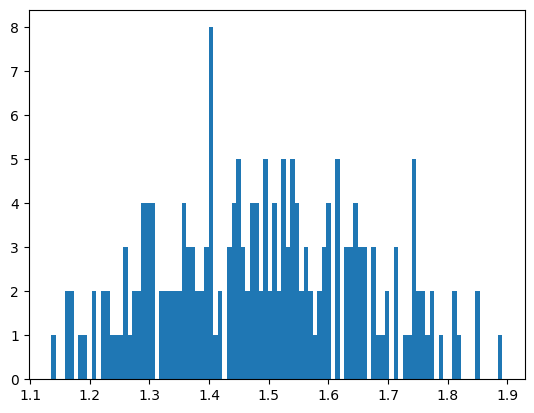

In [37]:
plt.hist(d_train, bins=100)
plt.show()

In [71]:
def compute_probs(qs, scaling_fac=7):
    ham = qkernel.hamiltonian.QuTiPHamiltonian(qs*scaling_fac)
    sim = qkernel.simulator.QuTiPSimulator(ham.generate_hamiltonians_list())
    return np.array(sim.get_probabilities_list())[:, :, 0]

In [72]:
p_train = compute_probs(q_train[:, :, None])
p_test = compute_probs(q_test[:, :, None])
print(p_train.shape, p_test.shape)

(200, 4) (10, 4)


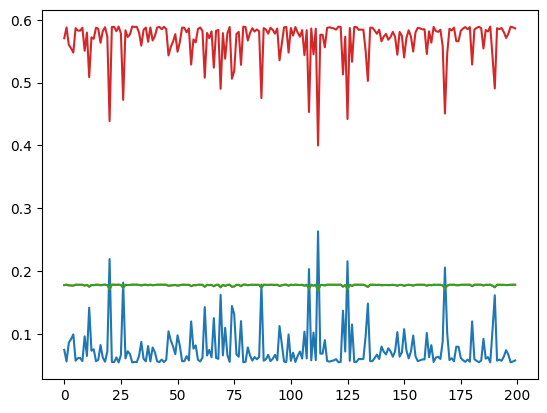

In [73]:
plt.plot(p_train[:, 0])
plt.plot(p_train[:, 1])
plt.plot(p_train[:, 2])
plt.plot(p_train[:, 3])

In [74]:
def radial_hopping(r):
    return 1.0 / r**3

In [75]:
t_train = radial_hopping(d_train)
t_test = radial_hopping(d_test)
print(t_test)

[0.29986412 0.42839389 0.3290954  0.37908596 0.26195105 0.22269306
 0.32045839 0.32970254 0.39716453 0.15646259]


In [76]:
def solve_hubbard(hopping):
    t_mat = np.array([[0., hopping], [hopping, 0.]])
    calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=2)
    ham = calc.hopping(t_mat) + np.diag(calc.doubles())
    return np.linalg.eigvalsh(ham)[0]

In [77]:
e_train = [solve_hubbard(t) for t in t_train]
e_test = [solve_hubbard(t) for t in t_test]

In [78]:
kernel = qkernel.kernel.Kernel(p_train=p_train, p_test=p_test, distance_fn="exp_js")
g_train = kernel.compute_gram_train()
g_test = kernel.compute_gram_test()

In [79]:
from sklearn.kernel_ridge import KernelRidge

In [80]:
model = KernelRidge(kernel="precomputed")
model.fit(g_train, e_train)
pred_train = model.predict(g_train)
pred_test = model.predict(g_test)

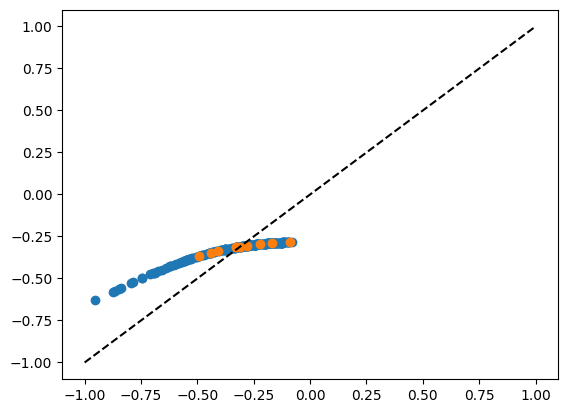

In [81]:
plt.scatter(e_train, pred_train)
plt.scatter(e_test, pred_test)
plt.plot([-1, 1], [-1, 1], ls='--', c='k')